# Visuals Notebook for Resource Usage

In [1]:
from helpers import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Load data for January 2024

In [2]:
year_2024_01 = process_gpu_data('24', '01')
year_2024_01

,time,bus,util,memory_throughput,user,project_x,job_id,scenario,qname,hostname,...,granted_pe,slots,task_number,cpu,options,pe_taskid,maxvmem,n_gpu,task_string,job_task
0,1704085201,00000000:17:00.0,90.0,72.0,zjguo,depend,3367552.undefined,1,ece,scc-216,...,omp8,8.0,0.0,93886.545949,"-U engineering,ece -u zjguo -l gpu_compute_cap...",NaN,1.175716e+11,1.0,undefined,3367552.undefined
1,1704085201,00000000:65:00.0,22.0,1.0,dgordon,textconv,3366341.undefined,1,ece,scc-216,...,omp,4.0,0.0,322113.971996,"-U ece,engineering -u dgordon -l gpu_compute_c...",NaN,3.344766e+11,1.0,undefined,3366341.undefined
2,1704085201,00000000:CA:00.0,83.0,52.0,animikh,rlvn,3321766.undefined,1,ece,scc-216,...,omp8,8.0,0.0,689953.903543,"-U rlvn,ece,academic,engineering -u animikh -l...",NaN,5.860159e+11,2.0,undefined,3321766.undefined
3,1704085201,00000000:E3:00.0,80.0,46.0,animikh,rlvn,3321766.undefined,1,ece,scc-216,...,omp8,8.0,0.0,689953.903543,"-U rlvn,ece,academic,engineering -u animikh -l...",NaN,5.860159e+11,2.0,undefined,3321766.undefined
4,1704085501,00000000:17:00.0,92.0,75.0,zjguo,depend,3367552.undefined,1,ece,scc-216,...,omp8,8.0,0.0,93886.545949,"-U engineering,ece -u zjguo -l gpu_compute_cap...",NaN,1.175716e+11,1.0,undefined,3367552.undefined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619022,1706762701,00000000:82:00.0,0.0,0.0,Missing Values,Missing Values,4193291.undefined,2,onrcc-gpu,scc-x03,...,omp,4.0,0.0,5609.930000,"-U onrcc,engineering -u dche1 -l gpu_compute_c...",NaN,3.619530e+10,2.0,undefined,4193291.undefined
2619023,1706763001,00000000:02:00.0,0.0,0.0,Missing Values,Missing Values,4193291.undefined,2,onrcc-gpu,scc-x03,...,omp,4.0,0.0,5609.930000,"-U onrcc,engineering -u dche1 -l gpu_compute_c...",NaN,3.619530e+10,2.0,undefined,4193291.undefined
2619024,1706763001,00000000:82:00.0,0.0,0.0,Missing Values,Missing Values,4193291.undefined,2,onrcc-gpu,scc-x03,...,omp,4.0,0.0,5609.930000,"-U onrcc,engineering -u dche1 -l gpu_compute_c...",NaN,3.619530e+10,2.0,undefined,4193291.undefined
2619025,1706763301,00000000:02:00.0,0.0,0.0,Missing Values,Missing Values,4193291.undefined,2,onrcc-gpu,scc-x03,...,omp,4.0,0.0,5609.930000,"-U onrcc,engineering -u dche1 -l gpu_compute_c...",NaN,3.619530e+10,2.0,undefined,4193291.undefined


In [3]:
year_2024_01['scenario'].value_counts()

scenario
0    1368008
1     862425
2     388583
3         11
Name: count, dtype: int64

In [4]:
node_status = pd.read_csv('/projectnb/scv/utilization/katia/queue_info.csv')
node_status_mapping = node_status.set_index('queuename')['class_own'].to_dict()
year_2024_01['class_own'] = year_2024_01['qname'].map(node_status_mapping)
node_status_mapping = node_status.set_index('queuename')['class_user'].to_dict()
year_2024_01['class_user'] = year_2024_01['qname'].map(node_status_mapping)

In [5]:
# determine if job is ondemand/interactive vs batch
year_2024_01['job_interactive'] = (year_2024_01['job_name'].str.startswith("ood")) | (year_2024_01['job_name'] == "QRLOGIN")

In [6]:
node_status

,queuename,queuetotal,class_user,class_own,class_util
0,4,4,shared,shared,compute
1,a,a,shared,shared,compute
2,a100,a100,shared,shared,gpu
3,a128,a,shared,shared,compute
4,a40,a40,shared,shared,gpu
...,...,...,...,...,...
288,withers01-pub,withers01-pub,shared,buyin,buyin
289,wys-text,wys-text-pub,buyin,buyin,buyin
290,wys-text-pub,wys-text-pub,shared,buyin,buyin
291,y,y,shared,shared,compute


## Look at GPU average utilization over the time period

In [7]:
# Convert 'time' to datetime
year_2024_01['time'] = pd.to_datetime(year_2024_01['time'], unit='s')

# Resample utilization by 1-hour intervals (mean utilization)
gpu_util_hourly = year_2024_01.resample('1H', on='time')['util'].mean()

# Fill nans with 0
gpu_util_hourly[gpu_util_hourly.isna()] = 0

# Resample utilization by 1-hour intervals (mean utilization)
gpu_util_hourly_buyin = year_2024_01[year_2024_01['class_own']=='buyin'].resample('1H', on='time')['util'].mean()
gpu_util_hourly_shared = year_2024_01[year_2024_01['class_own']=='shared'].resample('1H', on='time')['util'].mean()

# Fill nans with 0
gpu_util_hourly[gpu_util_hourly.isna()] = 0
gpu_util_hourly_buyin[gpu_util_hourly_buyin.isna()] = 0
gpu_util_hourly_shared[gpu_util_hourly_shared.isna()] = 0



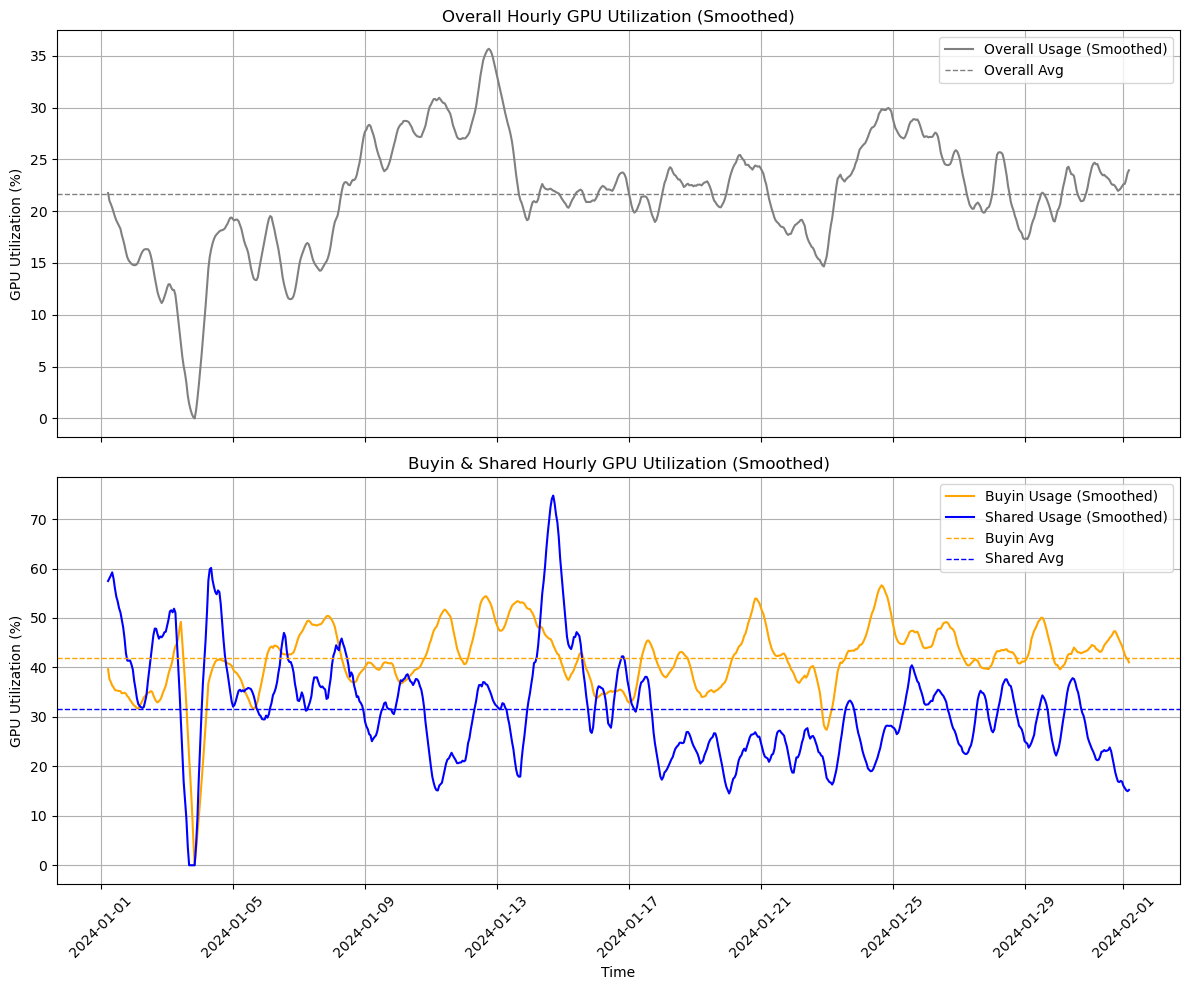

In [8]:
# Define moving average window size
window_size = 10  # Adjust as needed

# Compute moving averages
gpu_util_hourly_smooth = gpu_util_hourly.rolling(window=window_size, min_periods=1).mean()
gpu_util_hourly_buyin_smooth = gpu_util_hourly_buyin.rolling(window=window_size, min_periods=1).mean()
gpu_util_hourly_shared_smooth = gpu_util_hourly_shared.rolling(window=window_size, min_periods=1).mean()

# Create subplots: 2 rows, 1 column
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot Overall Usage on the first subplot
sns.lineplot(ax=axes[0], x=gpu_util_hourly.index, y=gpu_util_hourly_smooth.values, color="gray", label="Overall Usage (Smoothed)")
axes[0].axhline(gpu_util_hourly_smooth.mean(), color="gray", linestyle="dashed", linewidth=1, label="Overall Avg")
axes[0].set_ylabel("GPU Utilization (%)")
axes[0].set_title("Overall Hourly GPU Utilization (Smoothed)")
axes[0].legend()
axes[0].grid()

# Plot Buyin & Shared Usage on the second subplot
sns.lineplot(ax=axes[1], x=gpu_util_hourly_buyin.index, y=gpu_util_hourly_buyin_smooth.values, color="orange", label="Buyin Usage (Smoothed)")
sns.lineplot(ax=axes[1], x=gpu_util_hourly_shared.index, y=gpu_util_hourly_shared_smooth.values, color="blue", label="Shared Usage (Smoothed)")
axes[1].axhline(gpu_util_hourly_buyin_smooth.mean(), color="orange", linestyle="dashed", linewidth=1, label="Buyin Avg")
axes[1].axhline(gpu_util_hourly_shared_smooth.mean(), color="blue", linestyle="dashed", linewidth=1, label="Shared Avg")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("GPU Utilization (%)")
axes[1].set_title("Buyin & Shared Hourly GPU Utilization (Smoothed)")
axes[1].legend()
axes[1].grid()

# Adjust layout for better spacing
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Top GPU Users & Wasters by User, Project
### Summed by util, rather than count

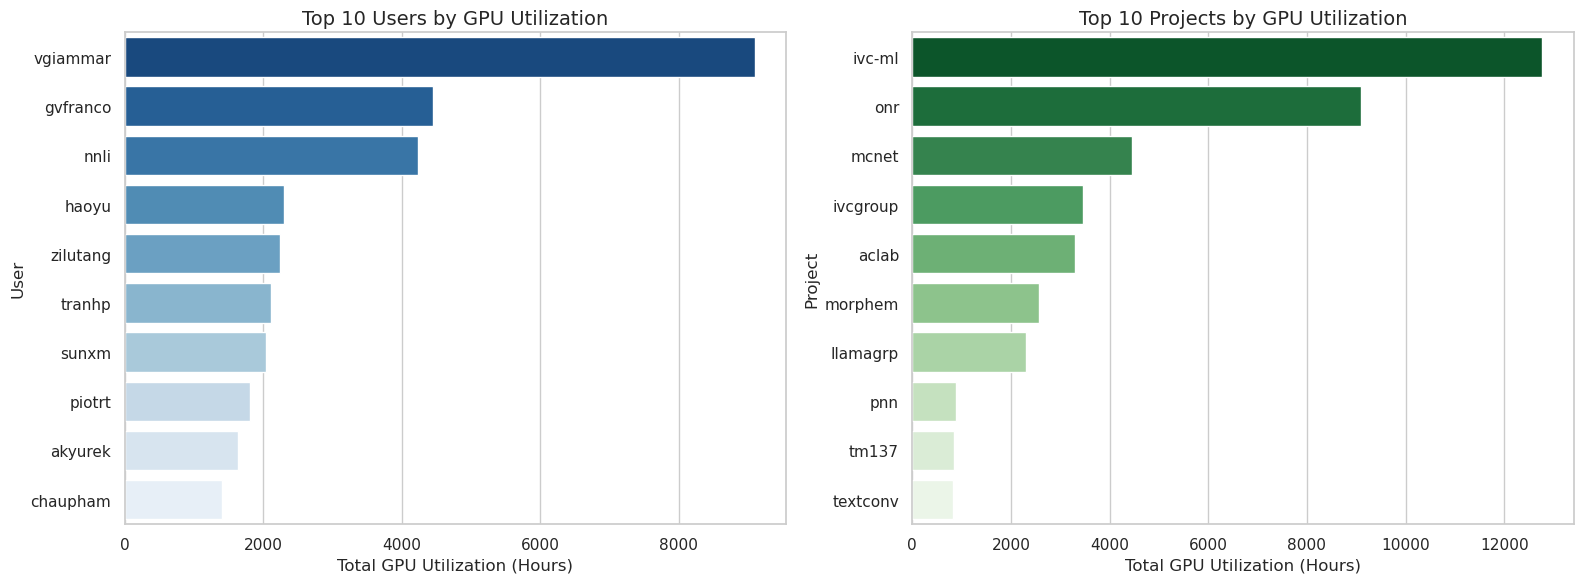

In [9]:
# Group by user and sum utilization
top_users = year_2024_01.groupby("user")["util"].sum().nlargest(10)

# Group by project and sum utilization
top_projects = year_2024_01.groupby("project_x")["util"].sum().nlargest(10)

# Set Seaborn style
sns.set_theme(style="whitegrid")

# Create subplots for users and projects
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot top users
sns.barplot(x=top_users.values / 1200, y=top_users.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Top 10 Users by GPU Utilization", fontsize=14)
axes[0].set_xlabel("Total GPU Utilization (Hours)", fontsize=12)
axes[0].set_ylabel("User", fontsize=12)

# Plot top projects
sns.barplot(x=top_projects.values / 1200, y=top_projects.index, ax=axes[1], palette="Greens_r")
axes[1].set_title("Top 10 Projects by GPU Utilization", fontsize=14)
axes[1].set_xlabel("Total GPU Utilization (Hours)", fontsize=12)
axes[1].set_ylabel("Project", fontsize=12)

# Adjust layout
plt.tight_layout()
plt.show()


In [10]:
year_2024_01[year_2024_01['user']=='vgiammar']

,time,bus,util,memory_throughput,user,project_x,job_id,scenario,qname,hostname,...,cpu,options,pe_taskid,maxvmem,n_gpu,task_string,job_task,class_own,class_user,job_interactive
998129,2024-01-01 05:00:02,00000000:4F:00.0,3.0,1.0,vgiammar,onr,-,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
998133,2024-01-01 05:00:02,00000000:D5:00.0,86.0,74.0,vgiammar,onr,3342774.undefined,1,neuro-autonomy,scc-302,...,202937.520000,"-U noc-lab,engineering,neuromorphics,ece,neuro...",NaN,7.896011e+10,1.0,undefined,3342774.undefined,buyin,buyin,False
998134,2024-01-01 05:00:02,00000000:D6:00.0,77.0,71.0,vgiammar,onr,3320488.undefined,1,neuro-autonomy,scc-302,...,443975.280000,"-U noc-lab,neuromorphics,neuro-autonomy,onrcc,...",NaN,8.865793e+10,1.0,undefined,3320488.undefined,buyin,buyin,False
998135,2024-01-01 05:05:01,00000000:4F:00.0,4.0,1.0,vgiammar,onr,-,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
998139,2024-01-01 05:05:01,00000000:D5:00.0,84.0,72.0,vgiammar,onr,3342774.undefined,1,neuro-autonomy,scc-302,...,202937.520000,"-U noc-lab,engineering,neuromorphics,ece,neuro...",NaN,7.896011e+10,1.0,undefined,3342774.undefined,buyin,buyin,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2037892,2024-02-01 04:50:01,00000000:17:00.0,65.0,29.0,vgiammar,onr,4198215.undefined,1,neuro-autonomy,scc-210,...,175979.425439,"-U onrcc,ece,academic,engineering -u aam -l gp...",NaN,7.503981e+11,1.0,undefined,4198215.undefined,buyin,buyin,False
2037894,2024-02-01 04:50:01,00000000:CA:00.0,54.0,26.0,vgiammar,onr,3955137.undefined,1,neuro-autonomy,scc-210,...,148786.520000,"-U neuromorphics,onrcc,ece,engineering -u vgia...",NaN,7.111015e+10,1.0,undefined,3955137.undefined,buyin,buyin,False
2037895,2024-02-01 04:50:01,00000000:E3:00.0,73.0,40.0,vgiammar,onr,3955138.undefined,1,neuro-autonomy,scc-210,...,152313.260000,"-U neuromorphics,onrcc,ece,engineering -u vgia...",NaN,7.112894e+10,1.0,undefined,3955138.undefined,buyin,buyin,False
2037896,2024-02-01 04:55:01,00000000:17:00.0,42.0,10.0,vgiammar,onr,4198215.undefined,1,neuro-autonomy,scc-210,...,175979.425439,"-U onrcc,ece,academic,engineering -u aam -l gp...",NaN,7.503981e+11,1.0,undefined,4198215.undefined,buyin,buyin,False


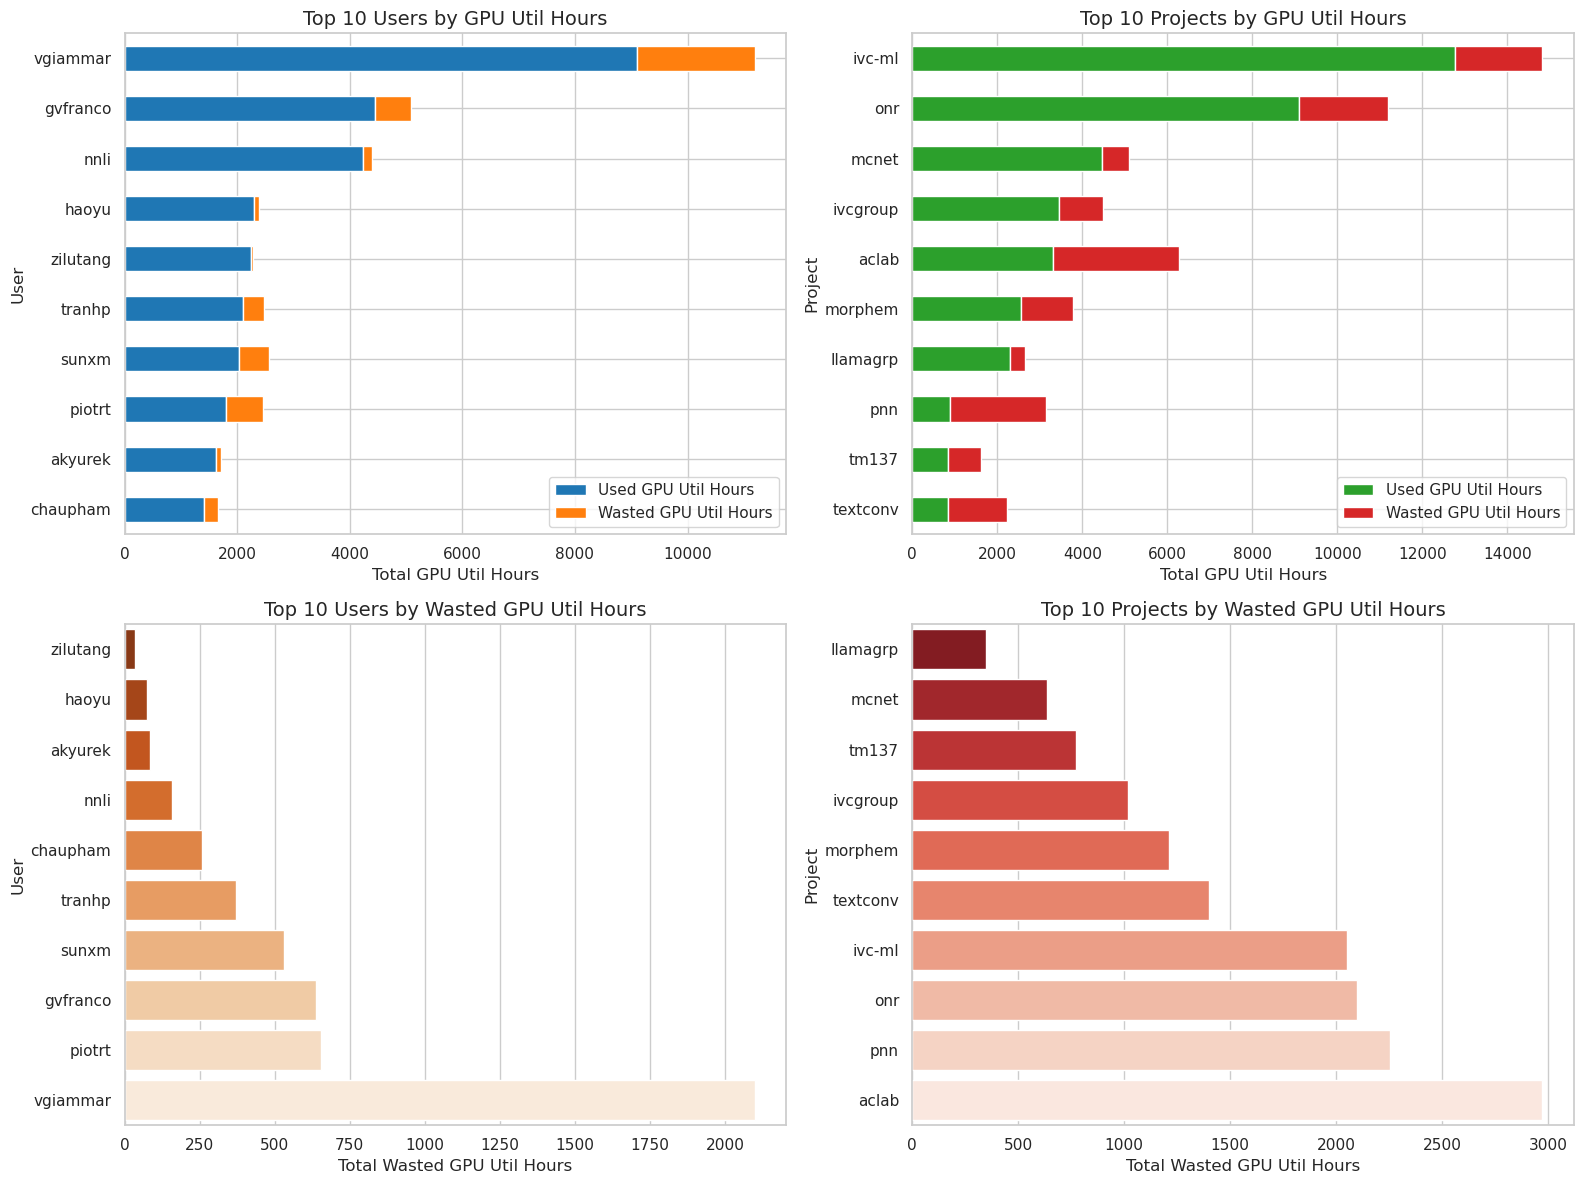

In [11]:
# Convert GPU usage to GPU hours
year_2024_01["gpu_hours"] = year_2024_01["util"] * (1/12) * (1/100) #* year_2024_01["n_gpu"]
year_2024_01["wasted_gpu_hours"] = (100 - year_2024_01["util"]) * (1/12) * (1/100) #* year_2024_01["n_gpu"]

# Aggregate GPU hours and wasted GPU hours for users and projects
top_users_gpu = year_2024_01.groupby("user")[["gpu_hours", "wasted_gpu_hours"]].sum().nlargest(10, "gpu_hours")
top_projects_gpu = year_2024_01.groupby("project_x")[["gpu_hours", "wasted_gpu_hours"]].sum().nlargest(10, "gpu_hours")

# Get the top users and projects by wasted GPU hours (sorted properly)
top_users_wasted = top_users_gpu.sort_values("wasted_gpu_hours", ascending=True)
top_projects_wasted = top_projects_gpu.sort_values("wasted_gpu_hours", ascending=True)

# Set Seaborn style
sns.set_theme(style="whitegrid")

# Create subplots for users and projects
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot top users (used & wasted)
top_users_gpu.sort_values("gpu_hours", ascending=True).plot(kind="barh", stacked=True, ax=axes[0, 0], color=["#1f77b4", "#ff7f0e"])
axes[0, 0].set_title("Top 10 Users by GPU Util Hours", fontsize=14)
axes[0, 0].set_xlabel("Total GPU Util Hours", fontsize=12)
axes[0, 0].set_ylabel("User", fontsize=12)
axes[0, 0].legend(["Used GPU Util Hours", "Wasted GPU Util Hours"])

# Plot top projects (used & wasted)
top_projects_gpu.sort_values("gpu_hours", ascending=True).plot(kind="barh", stacked=True, ax=axes[0, 1], color=["#2ca02c", "#d62728"])
axes[0, 1].set_title("Top 10 Projects by GPU Util Hours", fontsize=14)
axes[0, 1].set_xlabel("Total GPU Util Hours", fontsize=12)
axes[0, 1].set_ylabel("Project", fontsize=12)
axes[0, 1].legend(["Used GPU Util Hours", "Wasted GPU Util Hours"])

# Plot wasted GPU hours for users (Sorted by wasted_gpu_hours)
sns.barplot(x=top_users_wasted["wasted_gpu_hours"], y=top_users_wasted.index, ax=axes[1, 0], palette="Oranges_r")
axes[1, 0].set_title("Top 10 Users by Wasted GPU Util Hours", fontsize=14)
axes[1, 0].set_xlabel("Total Wasted GPU Util Hours", fontsize=12)
axes[1, 0].set_ylabel("User", fontsize=12)

# Plot wasted GPU hours for projects (Sorted by wasted_gpu_hours)
sns.barplot(x=top_projects_wasted["wasted_gpu_hours"], y=top_projects_wasted.index, ax=axes[1, 1], palette="Reds_r")
axes[1, 1].set_title("Top 10 Projects by Wasted GPU Util Hours", fontsize=14)
axes[1, 1].set_xlabel("Total Wasted GPU Util Hours", fontsize=12)
axes[1, 1].set_ylabel("Project", fontsize=12)

# Adjust layout
plt.tight_layout()
plt.show()

## Examine by Counts

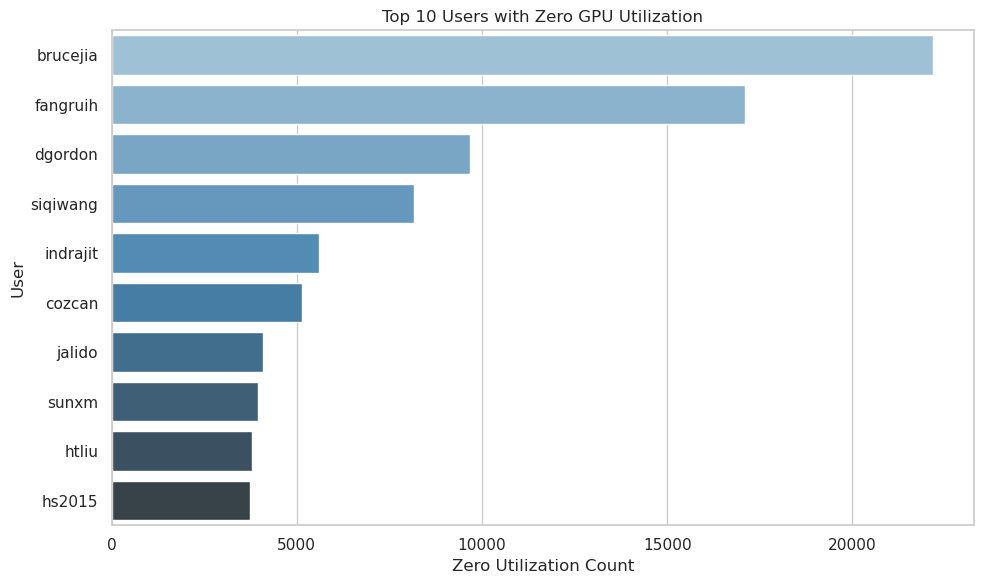

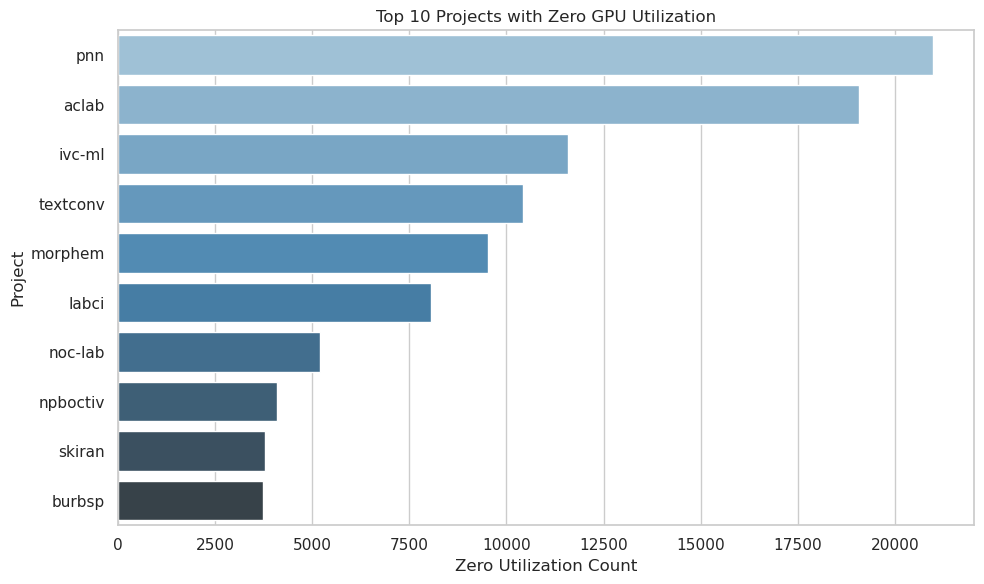

In [12]:
# Calculate the number of rows with zero utilization per user, note for scenario = 0
zero_util_users = year_2024_01[(year_2024_01['util'] == 0) & (year_2024_01['scenario'] != 0) & (year_2024_01['user'] != 'Missing Values')].dropna(subset=['user']).groupby('user').size().reset_index(name='zero_util_count')

# Calculate the number of rows with zero utilization per project
zero_util_projects = year_2024_01[(year_2024_01['util'] == 0) & (year_2024_01['scenario'] != 0) & (year_2024_01['user'] != 'Missing Values')].dropna(subset=['user']).groupby('project_x').size().reset_index(name='zero_util_count')

# Sort by zero_util_count in descending order for top users and projects
zero_util_users_sorted = zero_util_users.sort_values('zero_util_count', ascending=False).head(10)
zero_util_projects_sorted = zero_util_projects.sort_values('zero_util_count', ascending=False).head(10)

# Plot for top 10 users with zero GPU utilization
plt.figure(figsize=(10, 6))
sns.barplot(x='zero_util_count', y='user', data=zero_util_users_sorted, palette='Blues_d')
plt.title('Top 10 Users with Zero GPU Utilization')
plt.xlabel('Zero Utilization Count')
plt.ylabel('User')
plt.tight_layout()
plt.show()

# Plot for top 10 projects with zero GPU utilization
plt.figure(figsize=(10, 6))
sns.barplot(x='zero_util_count', y='project_x', data=zero_util_projects_sorted, palette='Blues_d')
plt.title('Top 10 Projects with Zero GPU Utilization')
plt.xlabel('Zero Utilization Count')
plt.ylabel('Project')
plt.tight_layout()
plt.show()

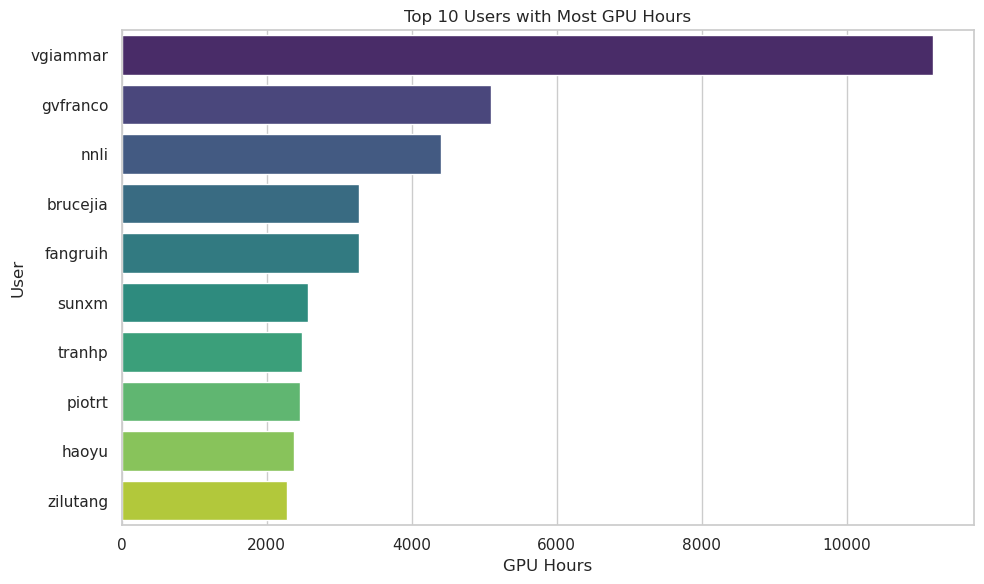

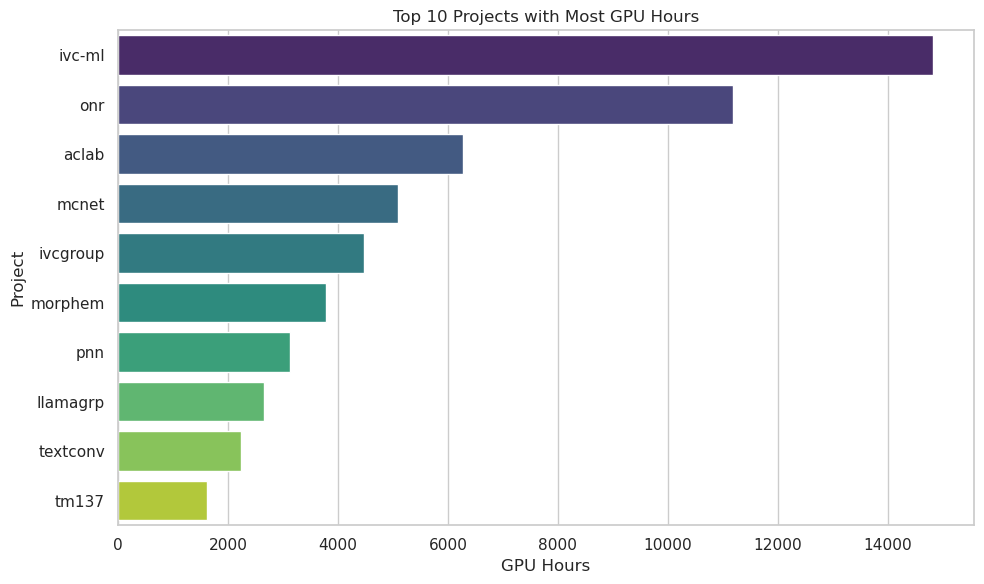

In [13]:
# Calculate the total GPU minutes per user (all rows, regardless of utilization)
gpu_minutes_users = year_2024_01.groupby('user').size().reset_index(name='gpu_minutes_count')
gpu_minutes_users = gpu_minutes_users[(gpu_minutes_users['user'] != '-') & (gpu_minutes_users['user'] != 'Missing Values')]
# Calculate the total GPU minutes per project
gpu_minutes_projects = year_2024_01.groupby('project_x').size().reset_index(name='gpu_minutes_count')
gpu_minutes_projects = gpu_minutes_projects[(gpu_minutes_projects['project_x'] != '-') & (gpu_minutes_projects['project_x'] != 'Missing Values')]

# Convert GPU minutes to GPU hours (since each row represents 5 minutes, divide by 12 to get hours)
gpu_minutes_users['gpu_hours_count'] = gpu_minutes_users['gpu_minutes_count'] / 12
gpu_minutes_projects['gpu_hours_count'] = gpu_minutes_projects['gpu_minutes_count'] / 12

# Sort by gpu_hours_count in descending order for top users and projects
gpu_minutes_users_sorted = gpu_minutes_users.sort_values('gpu_hours_count', ascending=False).head(10)
gpu_minutes_projects_sorted = gpu_minutes_projects.sort_values('gpu_hours_count', ascending=False).head(10)

# Plot for top 10 users with the most GPU hours
plt.figure(figsize=(10, 6))
sns.barplot(x='gpu_hours_count', y='user', data=gpu_minutes_users_sorted, palette='viridis')
plt.title('Top 10 Users with Most GPU Hours')
plt.xlabel('GPU Hours')
plt.ylabel('User')
plt.tight_layout()
plt.show()

# Plot for top 10 projects with the most GPU hours
plt.figure(figsize=(10, 6))
sns.barplot(x='gpu_hours_count', y='project_x', data=gpu_minutes_projects_sorted, palette='viridis')
plt.title('Top 10 Projects with Most GPU Hours')
plt.xlabel('GPU Hours')
plt.ylabel('Project')
plt.tight_layout()
plt.show()

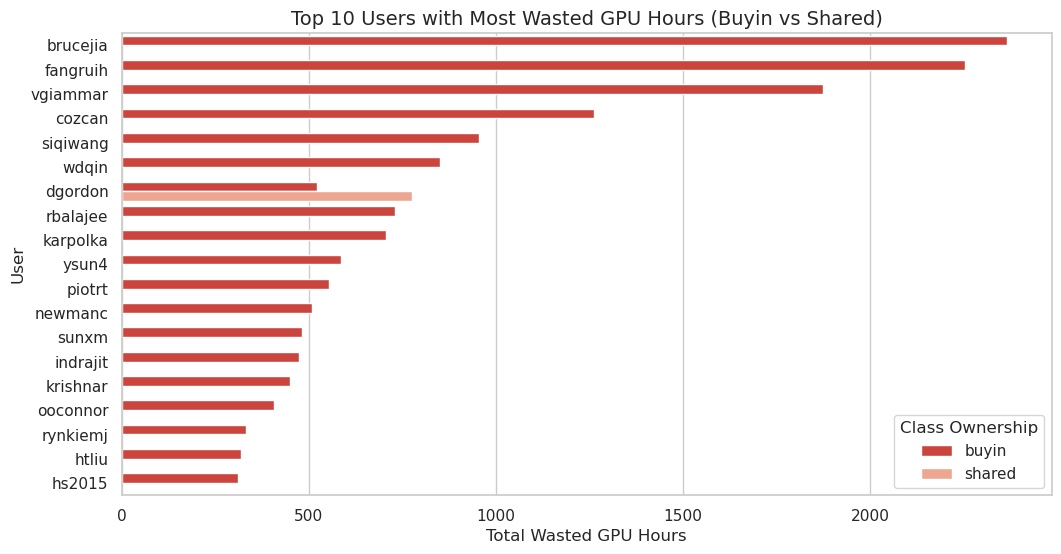

In [14]:
# Aggregate wasted GPU counts by user and class_own
top_users_wasted_gpu = (
    year_2024_01[year_2024_01["user"]!='Missing Values'].groupby(["user", "class_own"])["wasted_gpu_hours"]
    .sum()
    .reset_index()
    .sort_values("wasted_gpu_hours", ascending=False)
    .head(20)  # Top 10 users by wasted GPU hours
)

# Set Seaborn style
sns.set_theme(style="whitegrid")

# Create the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    x="wasted_gpu_hours", 
    y="user", 
    hue="class_own", 
    data=top_users_wasted_gpu, 
    palette="Reds_r"
)

# Customize the plot
plt.title("Top 10 Users with Most Wasted GPU Hours (Buyin vs Shared)", fontsize=14)
plt.xlabel("Total Wasted GPU Hours", fontsize=12)
plt.ylabel("User", fontsize=12)
plt.legend(title="Class Ownership")

# Show the plot
plt.show()


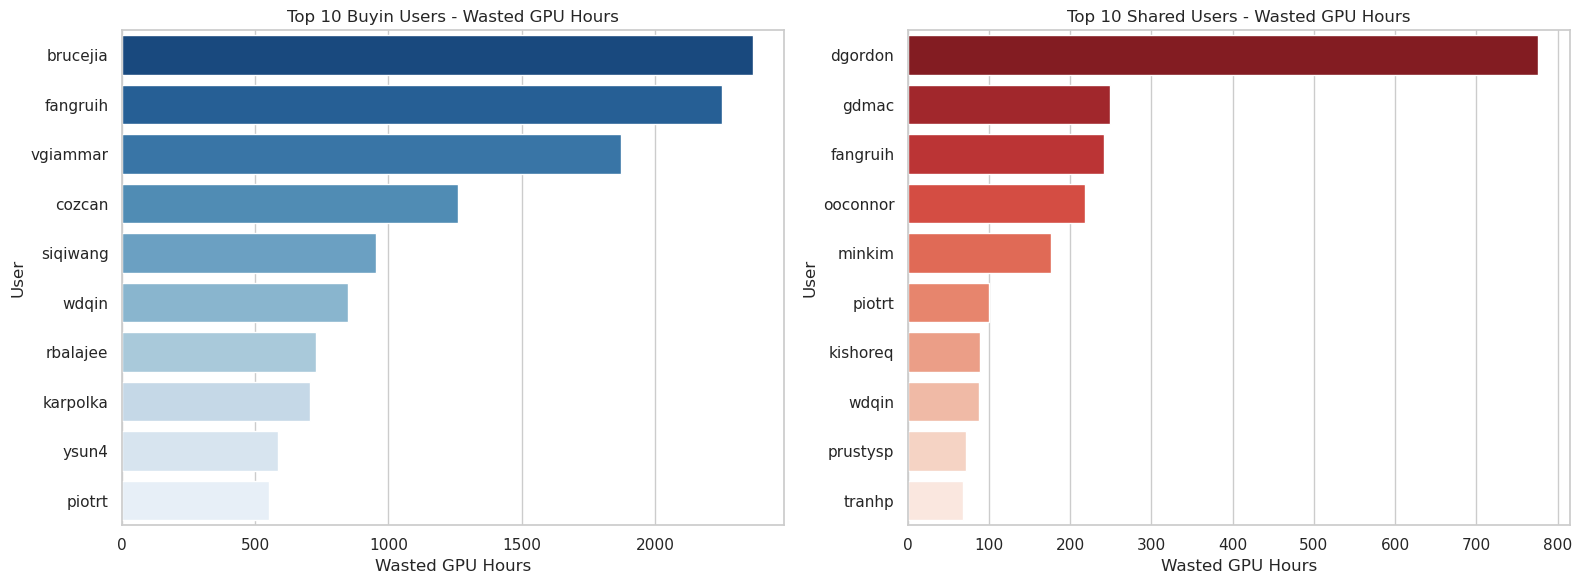

In [15]:
# Filter and get top 10 users for each class_own (buyin & shared)
top_buyin_users = (
    year_2024_01[(year_2024_01["class_own"] == "buyin") & (year_2024_01["user"] != "Missing Values")]
    .groupby("user")["wasted_gpu_hours"]
    .sum()
    .reset_index()
    .sort_values("wasted_gpu_hours", ascending=False)
    .head(10)
)

top_shared_users = (
    year_2024_01[(year_2024_01["class_own"] == "shared") & (year_2024_01["user"] != "Missing Values")]
    .groupby("user")["wasted_gpu_hours"]
    .sum()
    .reset_index()
    .sort_values("wasted_gpu_hours", ascending=False)
    .head(10)
)

# Set up the figure with two bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart for Buyin Users
sns.barplot(
    x="wasted_gpu_hours", 
    y="user", 
    data=top_buyin_users, 
    palette="Blues_r", 
    ax=axes[0]
)
axes[0].set_title("Top 10 Buyin Users - Wasted GPU Hours")
axes[0].set_xlabel("Wasted GPU Hours")
axes[0].set_ylabel("User")

# Bar chart for Shared Users
sns.barplot(
    x="wasted_gpu_hours", 
    y="user", 
    data=top_shared_users, 
    palette="Reds_r", 
    ax=axes[1]
)
axes[1].set_title("Top 10 Shared Users - Wasted GPU Hours")
axes[1].set_xlabel("Wasted GPU Hours")
axes[1].set_ylabel("User")

# Adjust layout
plt.tight_layout()
plt.show()

In [16]:
top_shared_users

,user,wasted_gpu_hours
16,dgordon,776.478333
23,gdmac,248.675000
21,fangruih,242.155833
47,ooconnor,218.802500
41,minkim,176.293333
48,piotrt,100.005833
37,kishoreq,88.820833
63,wdqin,88.290000
50,prustysp,71.906667
61,tranhp,68.637500


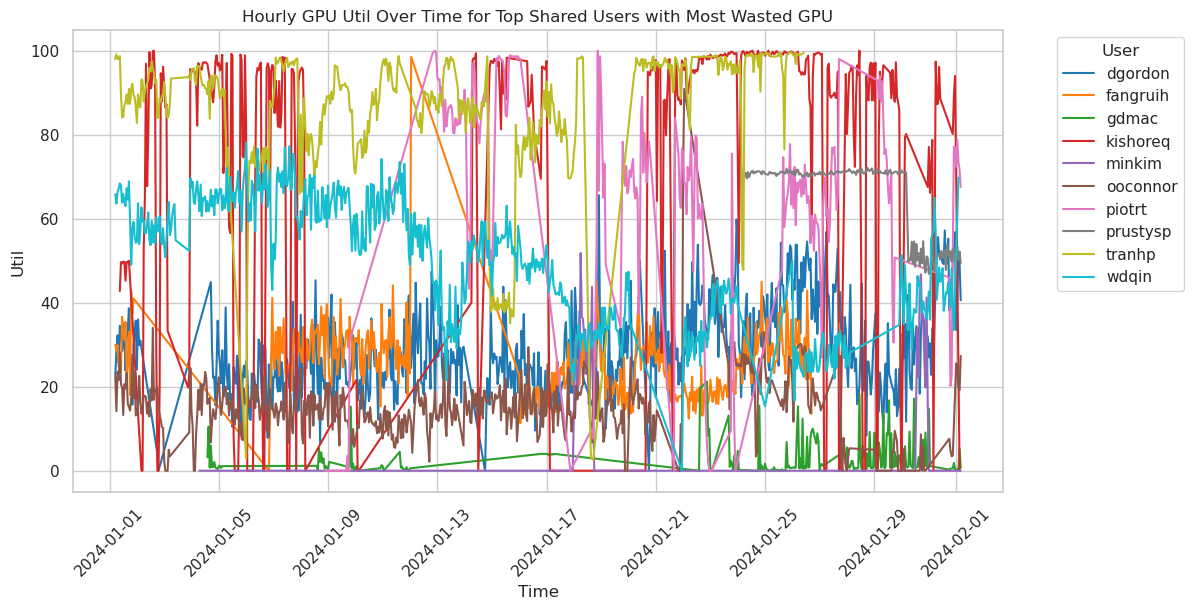

In [17]:
top_shared_users_list = top_shared_users['user'].tolist()
top_shared_users_data = year_2024_01[year_2024_01["user"].isin(top_shared_users_list)]
top_shared_users_time_series = top_shared_users_data.groupby(["time", "user"])["util"].mean().reset_index()
top_shared_users_time_series["time"] = pd.to_datetime(top_shared_users_time_series["time"])

# Ensure the time column is in datetime format
top_shared_users_time_series["time"] = pd.to_datetime(top_shared_users_time_series["time"])

# Set the 'time' column as the index
top_shared_users_time_series.set_index("time", inplace=True)

# Resample to an hourly frequency, summing GPU hours for each hour
top_shared_users_time_series_hourly = top_shared_users_time_series.groupby('user').resample('H').mean().reset_index()

# Plotting the resampled data
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=top_shared_users_time_series_hourly, 
    x="time", 
    y="util", 
    hue="user", 
    palette="tab10"
)
plt.title("Hourly GPU Util Over Time for Top Shared Users with Most Wasted GPU")
plt.xlabel("Time")
plt.ylabel("Util")
plt.xticks(rotation=45)
plt.legend(title="User", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()



## Interactive/ood vs. Batch

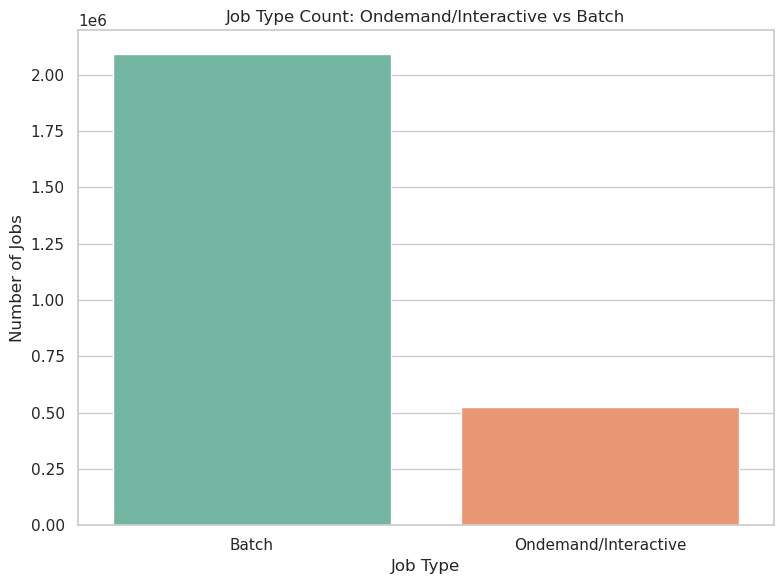

In [18]:
# CHECK THIS


# Count the number of jobs for each type (ondemand/interactive vs batch)
job_type_count = year_2024_01['job_interactive'].value_counts().reset_index()
job_type_count.columns = ['Job Type', 'Count']
job_type_count['Job Type'] = job_type_count['Job Type'].map({True: 'Ondemand/Interactive', False: 'Batch'})

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Job Type', y='Count', data=job_type_count, palette="Set2")
plt.title('Job Type Count: Ondemand/Interactive vs Batch')
plt.xlabel('Job Type')
plt.ylabel('Number of Jobs')
plt.tight_layout()
plt.show()


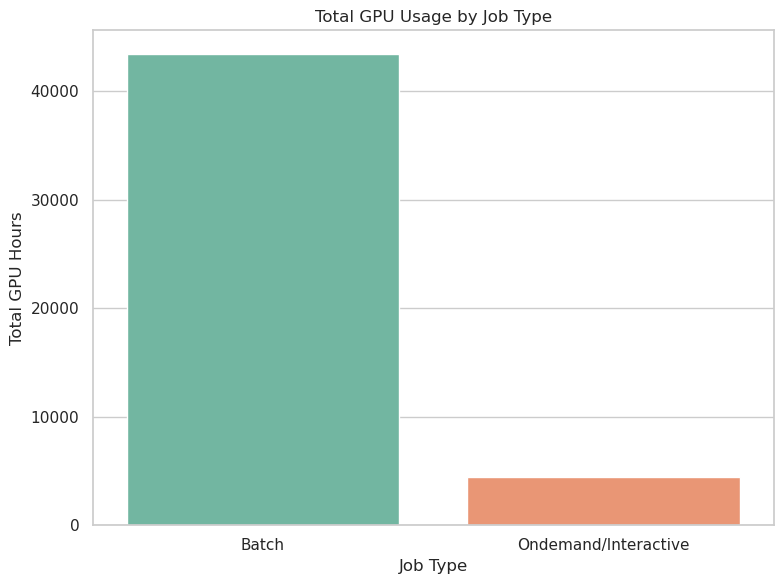

In [19]:
# Calculate total GPU usage for each job type
gpu_usage_by_job_type = year_2024_01.groupby('job_interactive')['gpu_hours'].sum().reset_index()
gpu_usage_by_job_type['job_interactive'] = gpu_usage_by_job_type['job_interactive'].map({True: 'Ondemand/Interactive', False: 'Batch'})

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x='job_interactive', y='gpu_hours', data=gpu_usage_by_job_type, palette="Set2")
plt.title('Total GPU Usage by Job Type')
plt.xlabel('Job Type')
plt.ylabel('Total GPU Hours')
plt.tight_layout()
plt.show()


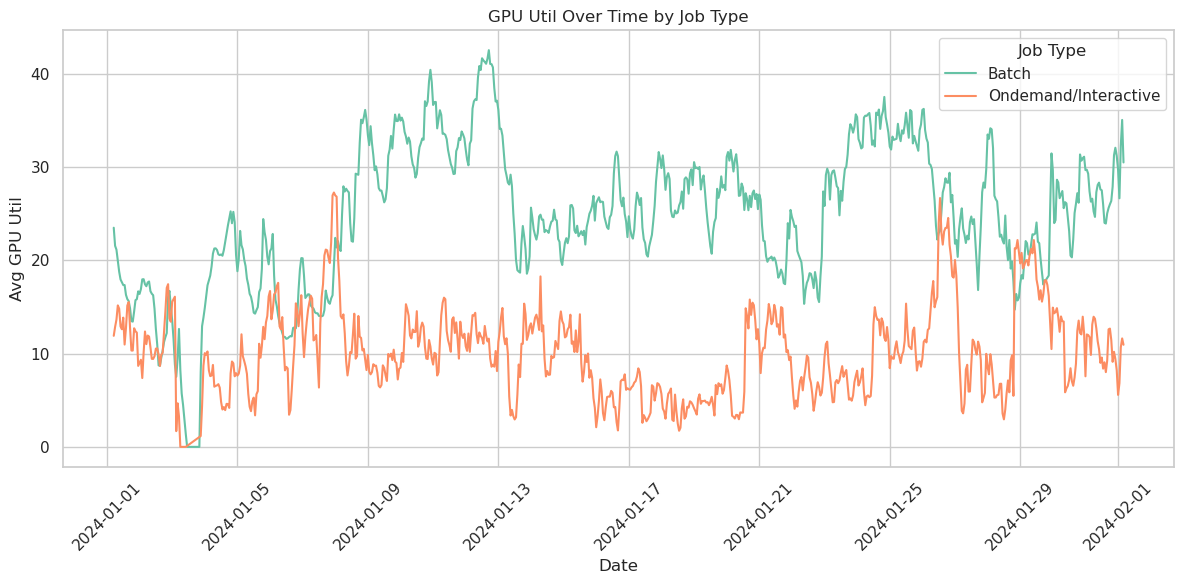

In [20]:
# Group by time and job type to get GPU usage over time
gpu_usage_time_by_type = year_2024_01.groupby([pd.Grouper(key='time', freq='1H'), 'job_interactive'])['util'].mean().reset_index()
gpu_usage_time_by_type['job_interactive'] = gpu_usage_time_by_type['job_interactive'].map({True: 'Ondemand/Interactive', False: 'Batch'})

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=gpu_usage_time_by_type, x='time', y='util', hue='job_interactive', palette="Set2")
plt.title('GPU Util Over Time by Job Type')
plt.xlabel('Date')
plt.ylabel('Avg GPU Util')
plt.xticks(rotation=45)
plt.legend(title="Job Type")
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
# Filter for interactive jobs, excluding missing values
interactive_jobs = year_2024_01[
    year_2024_01["job_interactive"] & (year_2024_01["user"] != "Missing Values")
]

# Group by user and calculate sum of wasted GPU hours & average GPU utilization
interactive_wasted_gpu = (
    interactive_jobs.groupby("user")
    .agg(
        wasted_gpu_hours=("wasted_gpu_hours", "sum"),
        avg_gpu_util=("util", "mean")  # Compute average GPU utilization
    )
    .reset_index()
)

# Sort by wasted GPU hours in descending order
top_interactive_wasters = interactive_wasted_gpu.sort_values(
    by="wasted_gpu_hours", ascending=False
)

# Display the top users who wasted the most GPU hours with their avg GPU util
print('Top Users Who Wasted the Most GPU Hours with Interactive/On Demand')
print(top_interactive_wasters.head(10))  # Adjust number as needed


Top Users Who Wasted the Most GPU Hours with Interactive/On Demand
         user  wasted_gpu_hours  avg_gpu_util
14   brucejia       2377.428333     27.343911
78   ooconnor        625.335833     14.659047
115     ysun4        602.029167     17.530251
74    newmanc        530.080000     31.609934
63   krishnar        487.620833     52.404018
50   indrajit        474.230000     10.424052
46      htliu        318.023333      1.566159
44     hs2015        311.494167      9.951096
83    rohan16        303.625833      1.152740
36      gdmac        257.717500      2.778686


### Find jobs with low util (<5%, basically 0), what users have a high proportion of these? Maybe they are requesting without using
#### NOTE: need to check over logic thoroughly, some incompleteness

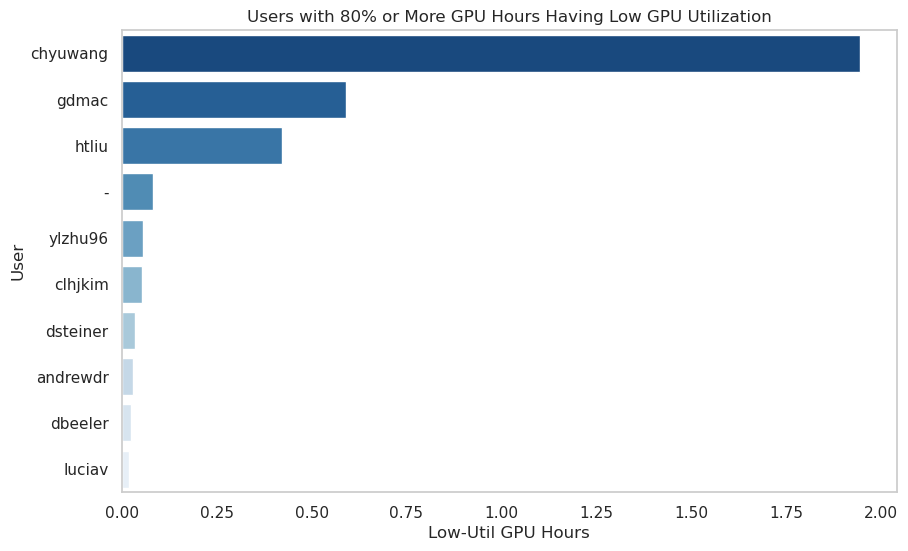

         user  total_gpu_hours  low_util_gpu_hours  low_util_percent
25   chyuwang        23.325000            1.943750          1.000000
48      gdmac         7.365833            0.591528          0.963684
59      htliu         5.060000            0.421667          1.000000
0           -         0.980000            0.081667          1.000000
140   ylzhu96         0.680833            0.056736          1.000000
27    clhjkim         0.633333            0.052778          1.000000
38   dsteiner         0.414167            0.034514          1.000000
12   andrewdr         0.345833            0.028819          1.000000
33    dbeeler         0.294167            0.024514          1.000000
82     luciav         0.236667            0.019722          1.000000
123   tornike         0.213333            0.017778          1.000000
31       cyw6         0.175833            0.014653          1.000000
145       zjb         0.152500            0.012708          1.000000
40   dsumigar         0.150833    

In [22]:
# Step 1: Calculate total GPU hours per job (grouped by job_id)
job_gpu_hours = year_2024_01.groupby('job_id')['gpu_hours'].sum().reset_index(name='total_gpu_hours')
job_avg_util = year_2024_01.groupby('job_id')['util'].mean().reset_index(name='avg_util')

# Merge the GPU hours with the average utilization data
job_data = pd.merge(job_gpu_hours, job_avg_util, on='job_id')

# Step 2: Mask jobs where the average utilization is below 5%
low_util_jobs_by_job = job_data[job_data['avg_util'] < 5]

# Step 3: Merge back with the original dataset to get rows related to those low-util jobs
low_util_jobs = pd.merge(year_2024_01, low_util_jobs_by_job[['job_id']], on='job_id', how='inner')

# Step 4: Calculate total GPU hours per user and total GPU hours for low-util jobs
total_gpu_hours_per_user = year_2024_01.groupby('user')['gpu_hours'].sum().reset_index(name='total_gpu_hours')
low_util_gpu_hours = low_util_jobs.groupby('user')['gpu_hours'].sum().reset_index(name='low_util_gpu_hours')

# Merge counts
user_util_summary = pd.merge(total_gpu_hours_per_user, low_util_gpu_hours, on='user', how='left').fillna(0)

# Step 5: Calculate the percentage of low-util GPU hours per user
user_util_summary['low_util_percent'] = user_util_summary['low_util_gpu_hours'] / user_util_summary['total_gpu_hours']

# Step 6: Filter users with 80% or more low-util GPU hours
consistent_low_util_users = user_util_summary[user_util_summary['low_util_percent'] >= 0.8]

consistent_low_util_users['low_util_gpu_hours'] /= 12

# Visualize the results
plt.figure(figsize=(10, 6))
sns.barplot(
    x='low_util_gpu_hours', 
    y='user', 
    data=consistent_low_util_users.sort_values('low_util_gpu_hours', ascending=False).head(10),
    palette='Blues_r'
)
plt.title('Users with 80% or More GPU Hours Having Low GPU Utilization')
plt.xlabel('Low-Util GPU Hours')
plt.ylabel('User')
plt.grid(axis='x')
plt.show()

# Display the result for reference
print(consistent_low_util_users.sort_values('low_util_gpu_hours', ascending=False))


In [23]:
year_2024_01[year_2024_01['user']==consistent_low_util_users.sort_values('low_util_gpu_hours', ascending=False)['user'].iloc[0]].options.iloc[0]

'-U ec500kb,ece,academic,engineering -u chyuwang -l gpu_compute_capability=7.0,gpu_type=A40,gpus=4,h_rt=864000 -soft -l buyin=TRUE -pe omp16 16 -P neurips'

### maybe an automated script can reach out to these users each month!

In [37]:
# year_2024_01['owner'].isna().sum(), (year_2024_01['user'] == 'Missing Values').sum()
# (np.int64(1496384), np.int64(388594))

year_2024_01[year_2024_01['owner'].isna()]['scenario'].value_counts()

scenario
0    1368008
1     127687
2        689
Name: count, dtype: int64

In [38]:
# these jobs end after january? thus missing some info
year_2024_01[(year_2024_01['owner'].isna()) & (year_2024_01['scenario']==1)]

,time,bus,util,memory_throughput,user,project_x,job_id,scenario,qname,hostname,...,pe_taskid,maxvmem,n_gpu,task_string,job_task,class_own,class_user,job_interactive,gpu_hours,wasted_gpu_hours
153138,2024-01-22 17:00:01,00000000:02:00.0,97.0,10.0,rbelisle,perpwm,3948976.1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.080833,0.002500
153139,2024-01-22 17:00:01,00000000:82:00.0,87.0,10.0,rbelisle,perpwm,3948976.2,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.072500,0.010833
153144,2024-01-22 17:15:01,00000000:02:00.0,9.0,1.0,rbelisle,perpwm,3949208.12,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.007500,0.075833
153145,2024-01-22 17:15:01,00000000:82:00.0,7.0,1.0,rbelisle,perpwm,3949208.11,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.005833,0.077500
153150,2024-01-22 17:30:01,00000000:02:00.0,9.0,1.0,rbelisle,perpwm,3949583.23,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.007500,0.075833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2613555,2024-01-22 17:00:01,00000000:02:00.0,97.0,10.0,rbelisle,perpwm,3948976.3,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.080833,0.002500
2613557,2024-01-22 17:05:01,00000000:02:00.0,41.0,8.0,rbelisle,perpwm,3948976.10,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.034167,0.049167
2613561,2024-01-22 17:15:01,00000000:02:00.0,8.0,1.0,rbelisle,perpwm,3949208.15,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.006667,0.076667
2613567,2024-01-22 17:30:01,00000000:02:00.0,6.0,1.0,rbelisle,perpwm,3949583.19,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.005000,0.078333


In [42]:
# see nan counts for non scenario 0 i.e. when gpu is actually reserved
year_2024_01[year_2024_01['scenario']!=0].isna().sum()

time                        0
bus                         0
util                        0
memory_throughput           0
user                        0
project_x                   0
job_id                      0
scenario                    0
qname                  128376
hostname               128376
owner                  128376
job_name               128376
job_number             128376
ux_submission_time     128376
ux_start_time          128376
ux_end_time            128376
failed                 128376
exit_status            128376
ru_wallclock           128376
ru_utime               128376
ru_maxrss              128376
project_y              128376
granted_pe             298574
slots                  128376
task_number            128376
cpu                    128376
options                128376
pe_taskid             1251019
maxvmem                128376
n_gpu                  133192
task_string            128376
job_task               128376
class_own              128376
class_user

In [48]:
year_2024_01[(year_2024_01["qname"].isna()) & (year_2024_01['scenario']!=0)].sort_values(by='time')#.iloc[0]

,time,bus,util,memory_throughput,user,project_x,job_id,scenario,qname,hostname,...,pe_taskid,maxvmem,n_gpu,task_string,job_task,class_own,class_user,job_interactive,gpu_hours,wasted_gpu_hours
229105,2024-01-01 05:00:01,00000000:1B:00.0,100.0,27.0,akyurek,llamagrp,3359345.3,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.083333,0.000000
2240154,2024-01-01 05:00:01,00000000:3B:00.0,97.0,15.0,gvfranco,mcnet,3366863.1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.080833,0.002500
945248,2024-01-01 05:00:01,00000000:D8:00.0,96.0,16.0,gvfranco,mcnet,3366863.27,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.080000,0.003333
945247,2024-01-01 05:00:01,00000000:3B:00.0,94.0,13.0,gvfranco,mcnet,3366863.40,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.078333,0.005000
1191978,2024-01-01 05:00:01,00000000:D8:00.0,95.0,14.0,gvfranco,mcnet,3366863.26,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.079167,0.004167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535617,2024-02-01 04:55:02,00000000:17:00.0,97.0,97.0,gvfranco,mcnet,4197929.233,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.080833,0.002500
1535618,2024-02-01 04:55:02,00000000:CA:00.0,98.0,97.0,gvfranco,mcnet,4197929.223,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.081667,0.001667
303195,2024-02-01 04:55:02,00000000:1D:00.0,100.0,27.0,zilutang,ivc-ml,4198101.3,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.083333,0.000000
1421085,2024-02-01 04:55:02,00000000:1A:00.0,54.0,16.0,gvfranco,mcnet,4197929.216,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.045000,0.038333


In [55]:
year_2024_01[year_2024_01['job_id']=='3359345.3'].sort_values(by='time').iloc[0]

time                  2024-01-01 05:00:01
bus                      00000000:1B:00.0
util                                100.0
memory_throughput                    27.0
user                              akyurek
project_x                        llamagrp
job_id                          3359345.3
scenario                                1
qname                                 NaN
hostname                              NaN
owner                                 NaN
job_name                              NaN
job_number                            NaN
ux_submission_time                    NaN
ux_start_time                         NaN
ux_end_time                           NaN
failed                                NaN
exit_status                           NaN
ru_wallclock                          NaN
ru_utime                              NaN
ru_maxrss                             NaN
project_y                             NaN
granted_pe                            NaN
slots                             

## seems like missing values maybe missing from not having prev/next year, so miss merging those since its from next month

In [47]:
year_2024_01[(year_2024_01["qname"].isna()) & (year_2024_01['scenario']!=0)].iloc[1000]

time                  2024-01-08 07:45:01
bus                      00000000:17:00.0
util                                 43.0
memory_throughput                    23.0
user                             gvfranco
project_x                           mcnet
job_id                        3530725.219
scenario                                1
qname                                 NaN
hostname                              NaN
owner                                 NaN
job_name                              NaN
job_number                            NaN
ux_submission_time                    NaN
ux_start_time                         NaN
ux_end_time                           NaN
failed                                NaN
exit_status                           NaN
ru_wallclock                          NaN
ru_utime                              NaN
ru_maxrss                             NaN
project_y                             NaN
granted_pe                            NaN
slots                             

In [60]:
def process_gpu_data(year: str, month: str) -> pd.DataFrame:
    """
    Processes GPU usage data for a given year and month by merging job records with node statistics.
    Loads job records for the specified year as well as the previous and next years if available.

    Parameters:
        year (str): Two-digit year string (e.g., "25" for 2025).
        month (str): Two-digit month string (e.g., "01" for January).

    Returns:
        pd.DataFrame: A merged DataFrame containing job and GPU usage records.
    """
    # Validate year format
    if not isinstance(year, str) or not year.isdigit() or len(year) != 2:
        raise ValueError(
            f"Invalid year format: {year}. Expected a two-digit string (e.g., '25' for 2025)."
        )

    # Validate month format
    if not isinstance(month, str) or not month.isdigit() or len(month) != 2:
        raise ValueError(
            f"Invalid month format: {month}. Expected a two-digit string (e.g., '01' for January)."
        )

    # Determine file paths for current, previous, and next years
    current_year_file = f"/projectnb/rcsmetrics/accounting/data/scc/20{year}.csv"
    prev_year_file = f"/projectnb/rcsmetrics/accounting/data/scc/20{int(year)-1:02d}.csv"
    next_year_file = f"/projectnb/rcsmetrics/accounting/data/scc/20{int(year)+1:02d}.csv"

    print(current_year_file, prev_year_file, next_year_file)

    # Load job records for available years
    job_dfs = []
    for file in [prev_year_file, current_year_file, next_year_file]:
        if os.path.exists(file):
            try:
                job_dfs.append(read_gpu_records(file))
            except Exception as e:
                print(f"Skipping corrupted or unreadable file: {file}")

    # Concatenate all available job data
    gpu_jobs = pd.concat(job_dfs, ignore_index=True) if job_dfs else pd.DataFrame()

    if gpu_jobs.empty:
        print(f"No job records found for year {year} and adjacent years.")
        return pd.DataFrame()

    # Process job records
    gpu_jobs["task_string"] = gpu_jobs["task_number"].astype(str)
    gpu_jobs.loc[~(gpu_jobs["options"].str.contains("-t")), "task_string"] = "undefined"
    gpu_jobs["job_task"] = (
        gpu_jobs["job_number"].astype(str) + "." + gpu_jobs["task_string"].astype(str)
    )

    # Get file paths for the specified month
    nodes = os.listdir("/project/scv/dugan/gpustats/data/")
    files = [
        f"/project/scv/dugan/gpustats/data/{node}/{year}{month}"
        for node in nodes
        if os.path.exists(f"/project/scv/dugan/gpustats/data/{node}/{year}{month}")
    ]

    # Process and merge data
    all_merged_dfs = []
    for file_name in files:
        try:
            gpu_records = pd.DataFrame(clean_gpu_data(file_name))
        except Exception as e:
            print(f"Skipping missing or corrupted file: {file_name}")
            continue

        merged_df = pd.merge(
            gpu_records, gpu_jobs, left_on="job_id", right_on="job_task", how="left"
        )
        all_merged_dfs.append(merged_df)

    # Return the final concatenated DataFrame
    return (
        pd.concat(all_merged_dfs, ignore_index=True)
        if all_merged_dfs
        else pd.DataFrame()
    )



year_2024_01_new = process_gpu_data('24', '01')
year_2024_01_new

/projectnb/rcsmetrics/accounting/data/scc/2024.csv /projectnb/rcsmetrics/accounting/data/scc/2023.csv /projectnb/rcsmetrics/accounting/data/scc/2025.csv


,time,bus,util,memory_throughput,user,project_x,job_id,scenario,qname,hostname,...,granted_pe,slots,task_number,cpu,options,pe_taskid,maxvmem,n_gpu,task_string,job_task
0,1704085201,00000000:17:00.0,90.0,72.0,zjguo,depend,3367552.undefined,1,ece,scc-216,...,omp8,8.0,0.0,93886.545949,"-U engineering,ece -u zjguo -l gpu_compute_cap...",NaN,1.175716e+11,1.0,undefined,3367552.undefined
1,1704085201,00000000:65:00.0,22.0,1.0,dgordon,textconv,3366341.undefined,1,ece,scc-216,...,omp,4.0,0.0,322113.971996,"-U ece,engineering -u dgordon -l gpu_compute_c...",NaN,3.344766e+11,1.0,undefined,3366341.undefined
2,1704085201,00000000:CA:00.0,83.0,52.0,animikh,rlvn,3321766.undefined,1,ece,scc-216,...,omp8,8.0,0.0,689953.903543,"-U rlvn,ece,academic,engineering -u animikh -l...",NaN,5.860159e+11,2.0,undefined,3321766.undefined
3,1704085201,00000000:E3:00.0,80.0,46.0,animikh,rlvn,3321766.undefined,1,ece,scc-216,...,omp8,8.0,0.0,689953.903543,"-U rlvn,ece,academic,engineering -u animikh -l...",NaN,5.860159e+11,2.0,undefined,3321766.undefined
4,1704085501,00000000:17:00.0,92.0,75.0,zjguo,depend,3367552.undefined,1,ece,scc-216,...,omp8,8.0,0.0,93886.545949,"-U engineering,ece -u zjguo -l gpu_compute_cap...",NaN,1.175716e+11,1.0,undefined,3367552.undefined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619022,1706762701,00000000:82:00.0,0.0,0.0,Missing Values,Missing Values,4193291.undefined,2,onrcc-gpu,scc-x03,...,omp,4.0,0.0,5609.930000,"-U onrcc,engineering -u dche1 -l gpu_compute_c...",NaN,3.619530e+10,2.0,undefined,4193291.undefined
2619023,1706763001,00000000:02:00.0,0.0,0.0,Missing Values,Missing Values,4193291.undefined,2,onrcc-gpu,scc-x03,...,omp,4.0,0.0,5609.930000,"-U onrcc,engineering -u dche1 -l gpu_compute_c...",NaN,3.619530e+10,2.0,undefined,4193291.undefined
2619024,1706763001,00000000:82:00.0,0.0,0.0,Missing Values,Missing Values,4193291.undefined,2,onrcc-gpu,scc-x03,...,omp,4.0,0.0,5609.930000,"-U onrcc,engineering -u dche1 -l gpu_compute_c...",NaN,3.619530e+10,2.0,undefined,4193291.undefined
2619025,1706763301,00000000:02:00.0,0.0,0.0,Missing Values,Missing Values,4193291.undefined,2,onrcc-gpu,scc-x03,...,omp,4.0,0.0,5609.930000,"-U onrcc,engineering -u dche1 -l gpu_compute_c...",NaN,3.619530e+10,2.0,undefined,4193291.undefined


In [59]:
year_2024_01_new[year_2024_01_new['scenario']!=0].isna().sum()

time                        0
bus                         0
util                        0
memory_throughput           0
user                        0
project_x                   0
job_id                      0
scenario                    0
qname                  128376
hostname               128376
owner                  128376
job_name               128376
job_number             128376
ux_submission_time     128376
ux_start_time          128376
ux_end_time            128376
failed                 128376
exit_status            128376
ru_wallclock           128376
ru_utime               128376
ru_maxrss              128376
project_y              128376
granted_pe             298574
slots                  128376
task_number            128376
cpu                    128376
options                128376
pe_taskid             1251019
maxvmem                128376
n_gpu                  133192
task_string            128376
job_task               128376
dtype: int64